<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 1**

---

# **Título do Projeto**:

Previsão de Carga Elétrica para Apoio ao Planejamento Energético Sustentável


In [1]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Bianca Rezk de Angelo Correa, 10435117' #@param {type:"string"}
Aluno2 = 'Bruna Fagundes Pereira Queiroz, 10433417' #@param {type:"string"}
Aluno3 = 'Caio Cesar Teixeira Rocha, 10435091' #@param {type:"string"}
Aluno4 = 'Livya Kaizer de Albuquerque, 10433409' #@param {type:"string"}
Aluno5 = 'Lucas Feo Mazzei, 10433452' #@param {type:"string"}


# **Introdução**

Este projeto está inserido na área de Ciência de Dados aplicada a séries temporais, com foco no domínio de energia elétrica. O problema abordado é a previsão da demanda de eletricidade em diferentes clientes ao longo do tempo, utilizando dados históricos medidos em intervalos de 15 minutos.

A base selecionada (Electricity Load Diagrams 2011-2014, UCI) reúne o consumo de 370 clientes entre 2011 e 2014, permitindo estudar padrões de tendência, sazonalidade e variações de curto prazo. A partir desse contexto, o trabalho busca investigar como técnicas de análise e modelagem de séries temporais podem apoiar o planejamento operacional de energia.

O tema se conecta aos ODS 9 (Indústria, inovação e infraestrutura) e 12 (Consumo e produção responsáveis), pois previsões mais precisas de carga contribuem para melhor uso da infraestrutura elétrica, redução de desperdícios e suporte a decisões mais eficientes no consumo energético.


# **Motivações e justificativa**

A previsão de demanda elétrica é um problema relevante para concessionárias, operadores de rede e grandes consumidores, porque erros de estimativa podem gerar custos elevados, sobrecarga de infraestrutura e desperdício de recursos. Em escala urbana e industrial, compreender o comportamento do consumo ao longo do tempo é essencial para planejamento, confiabilidade do sistema e definição de estratégias de eficiência energética.

Do ponto de vista acadêmico, o projeto oferece um caso real de alta dimensionalidade e granularidade temporal, adequado para praticar todo o ciclo de um produto analítico: entendimento do problema, exploração dos dados, preparação da série temporal e avaliação de modelos preditivos.

Do ponto de vista social e econômico, os resultados podem apoiar decisões voltadas ao uso responsável de energia, com potencial de reduzir perdas operacionais e melhorar o equilíbrio entre oferta e demanda, em linha com os princípios de sustentabilidade propostos pelos ODS trabalhados na disciplina.


# **Descrição da base de dados**

A base de dados utilizada é a **Electricity Load Diagrams 2011-2014** (UCI Machine Learning Repository, id=321), composta por medições de consumo elétrico de **370 clientes**.

No arquivo local `data/LD2011_2014.txt`, os dados estão em formato texto CSV com separador `;`, contendo:
- **1 coluna temporal** (primeira coluna, sem nome no cabeçalho), no formato `yyyy-mm-dd hh:mm:ss`;
- **370 colunas de consumo** (`MT_001` a `MT_370`), com valores numéricos de carga (kW).

A inspeção exploratória com DuckDB no arquivo completo indicou:
- **140.256 linhas** (instantes de tempo);
- **371 colunas** no total (tempo + 370 séries de clientes);
- periodicidade regular de **15 minutos** entre observações;
- intervalo temporal observado de **2011-01-01 00:15:00** até **2015-01-01 00:00:00**.

Um ponto importante de pré-processamento é que parte dos valores de consumo aparece com **vírgula como separador decimal** (ex.: `71,7703349282297`). Assim, antes da modelagem, será necessário padronizar essas colunas para tipo numérico (`float`) e garantir tratamento consistente de formatação.

Fonte da base: UCI Machine Learning Repository.


In [7]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile
import shutil

ZIP_URL = 'https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip'

def _raiz_projeto() -> Path:
    """Localiza a raiz do projeto a partir do diretório atual."""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p
    return Path.cwd()

def baixar_e_descompactar_electricity(destino: str = 'data', forcar_download: bool = False, remover_zip: bool = False):
    """Baixa e descompacta o dataset na pasta data da raiz do projeto."""
    raiz = _raiz_projeto()
    pasta = (raiz / destino).resolve()
    pasta.mkdir(parents=True, exist_ok=True)

    caminho_txt = pasta / 'LD2011_2014.txt'
    caminho_zip = pasta / 'electricityloaddiagrams20112014.zip'

    # Se o TXT já existe, evita novo download por padrão
    if caminho_txt.exists() and not forcar_download:
        return {
            'data_dir': str(pasta),
            'zip_path': str(caminho_zip),
            'txt_path': str(caminho_txt),
            'status': 'arquivo_existente'
        }

    if forcar_download or not caminho_zip.exists():
        urlretrieve(ZIP_URL, caminho_zip)

    with zipfile.ZipFile(caminho_zip, 'r') as zf:
        zf.extractall(pasta)

    # Remove arquivo auxiliar criado em alguns sistemas
    pasta_macos = pasta / '__MACOSX'
    if pasta_macos.exists():
        shutil.rmtree(pasta_macos)

    if not caminho_txt.exists():
        raise FileNotFoundError('LD2011_2014.txt não foi encontrado após a descompactação.')

    if remover_zip and caminho_zip.exists():
        caminho_zip.unlink()

    return {
        'data_dir': str(pasta),
        'zip_path': str(caminho_zip),
        'txt_path': str(caminho_txt),
        'status': 'ok'
    }

# Exemplo de uso
info_dataset = baixar_e_descompactar_electricity(destino='data')
info_dataset


{'data_dir': 'C:\\Users\\Caio Rocha\\Documents\\code\\cdProjetoAplicadoIV\\data',
 'zip_path': 'C:\\Users\\Caio Rocha\\Documents\\code\\cdProjetoAplicadoIV\\data\\electricityloaddiagrams20112014.zip',
 'txt_path': 'C:\\Users\\Caio Rocha\\Documents\\code\\cdProjetoAplicadoIV\\data\\LD2011_2014.txt',
 'status': 'arquivo_existente'}

# **Exploração de dados (pandas)**

A seguir, estão as etapas de exploração utilizadas para validar estrutura, período, granularidade temporal e qualidade dos dados.


In [3]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path('../data/LD2011_2014.txt')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Arquivo não encontrado: {DATA_PATH.resolve()}')

# Leitura de amostra para inspecionar estrutura e tipos
amostra = pd.read_csv(DATA_PATH, sep=';', decimal=',', nrows=5, low_memory=False)
amostra = amostra.rename(columns={amostra.columns[0]: 'timestamp'})
amostra['timestamp'] = pd.to_datetime(amostra['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

print(f'Linhas da amostra: {len(amostra)}')
print(f'Quantidade de colunas: {amostra.shape[1]}')
print('Primeiras colunas:', amostra.columns[:8].tolist())
amostra.head()


Linhas da amostra: 5
Quantidade de colunas: 371
Primeiras colunas: ['timestamp', 'MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007']


,timestamp,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Perfil completo do arquivo usando leitura em chunks (eficiente em memória)
chunksize = 20000

total_linhas = 0
inicio_periodo = None
fim_periodo = None
intervalos = {}
nulos_por_coluna = None
ultimo_timestamp = None

for chunk in pd.read_csv(DATA_PATH, sep=';', decimal=',', chunksize=chunksize, low_memory=False):
    chunk = chunk.rename(columns={chunk.columns[0]: 'timestamp'})
    chunk['timestamp'] = pd.to_datetime(chunk['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

    colunas_consumo = [c for c in chunk.columns if c != 'timestamp']
    chunk[colunas_consumo] = chunk[colunas_consumo].apply(pd.to_numeric, errors='coerce')

    total_linhas += len(chunk)
    min_chunk = chunk['timestamp'].min()
    max_chunk = chunk['timestamp'].max()

    inicio_periodo = min_chunk if inicio_periodo is None else min(inicio_periodo, min_chunk)
    fim_periodo = max_chunk if fim_periodo is None else max(fim_periodo, max_chunk)

    nulos_chunk = chunk.isna().sum()
    if nulos_por_coluna is None:
        nulos_por_coluna = nulos_chunk
    else:
        nulos_por_coluna = nulos_por_coluna.add(nulos_chunk, fill_value=0)

    diffs = chunk['timestamp'].diff().dropna()
    if ultimo_timestamp is not None and not chunk.empty:
        diff_borda = chunk['timestamp'].iloc[0] - ultimo_timestamp
        diffs = pd.concat([pd.Series([diff_borda]), diffs], ignore_index=True)

    if not diffs.empty:
        contagens = diffs.value_counts()
        for intervalo, qtd in contagens.items():
            intervalos[intervalo] = intervalos.get(intervalo, 0) + int(qtd)

    if not chunk.empty:
        ultimo_timestamp = chunk['timestamp'].iloc[-1]

intervalos_serie = pd.Series(intervalos).sort_values(ascending=False)
nulos_por_coluna = nulos_por_coluna.sort_values(ascending=False)

resumo_geral = pd.DataFrame({
    'métrica': ['linhas', 'colunas_totais', 'colunas_consumo', 'início', 'fim', 'principal_intervalo'],
    'valor': [
        total_linhas,
        int(len(nulos_por_coluna)),
        int(len(nulos_por_coluna) - 1),
        inicio_periodo,
        fim_periodo,
        intervalos_serie.index[0] if not intervalos_serie.empty else None
    ]
})

print('Resumo geral:')
display(resumo_geral)

print('Top 5 intervalos observados:')
display(intervalos_serie.head(5).rename('frequência').to_frame())

print('Top 5 colunas com mais valores nulos:')
display(nulos_por_coluna.head(5).rename('qtd_nulos').to_frame())


Resumo geral:


,métrica,valor
0,linhas,140256
1,colunas_totais,371
2,colunas_consumo,370
3,início,2011-01-01 00:15:00
4,fim,2015-01-01 00:00:00
5,principal_intervalo,0 days 00:15:00


Top 5 intervalos observados:


,frequência
0 days 00:15:00,140255


Top 5 colunas com mais valores nulos:


,qtd_nulos
timestamp,0
MT_001,0
MT_002,0
MT_003,0
MT_004,0


In [5]:
# Estatísticas descritivas em um subconjunto de séries (exemplo)
colunas_exemplo = ['Unnamed: 0', 'MT_001', 'MT_050', 'MT_124', 'MT_200', 'MT_370']

df_exemplo = pd.read_csv(
    DATA_PATH,
    sep=';',
    decimal=',',
    usecols=lambda c: c in colunas_exemplo,
    low_memory=False
)
df_exemplo = df_exemplo.rename(columns={'Unnamed: 0': 'timestamp'})
df_exemplo['timestamp'] = pd.to_datetime(df_exemplo['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

for c in ['MT_001', 'MT_050', 'MT_124', 'MT_200', 'MT_370']:
    df_exemplo[c] = pd.to_numeric(df_exemplo[c], errors='coerce')

display(df_exemplo.head())
display(df_exemplo[['MT_001', 'MT_050', 'MT_124', 'MT_200', 'MT_370']].describe().T)


,timestamp,MT_001,MT_050,MT_124,MT_200,MT_370
0,2011-01-01 00:15:00,0.0,0.0,71.770335,428.414097,0.0
1,2011-01-01 00:30:00,0.0,0.0,71.770335,420.704846,0.0
2,2011-01-01 00:45:00,0.0,0.0,62.200957,398.678414,0.0
3,2011-01-01 01:00:00,0.0,0.0,71.770335,388.766520,0.0
4,2011-01-01 01:15:00,0.0,0.0,66.985646,363.436123,0.0


,count,mean,std,min,25%,50%,75%,max
MT_001,140256.0,3.970785,5.983965,0.0,0.000000,1.269036,2.538071,48.223350
MT_050,140256.0,123.780446,87.618168,0.0,46.263345,131.672598,192.170819,441.281139
MT_124,140256.0,280.763364,129.250493,0.0,157.894737,301.435407,373.205742,765.550239
MT_200,140256.0,848.640310,281.083900,0.0,591.409692,894.273128,1034.140969,1648.678414
MT_370,140256.0,8722.355145,9195.155777,0.0,0.000000,0.000000,17783.783784,30918.918919


# **Visualização inicial de série temporal**

Gráfico de exemplo para identificação visual do comportamento temporal (variação intradiária e tendência geral).


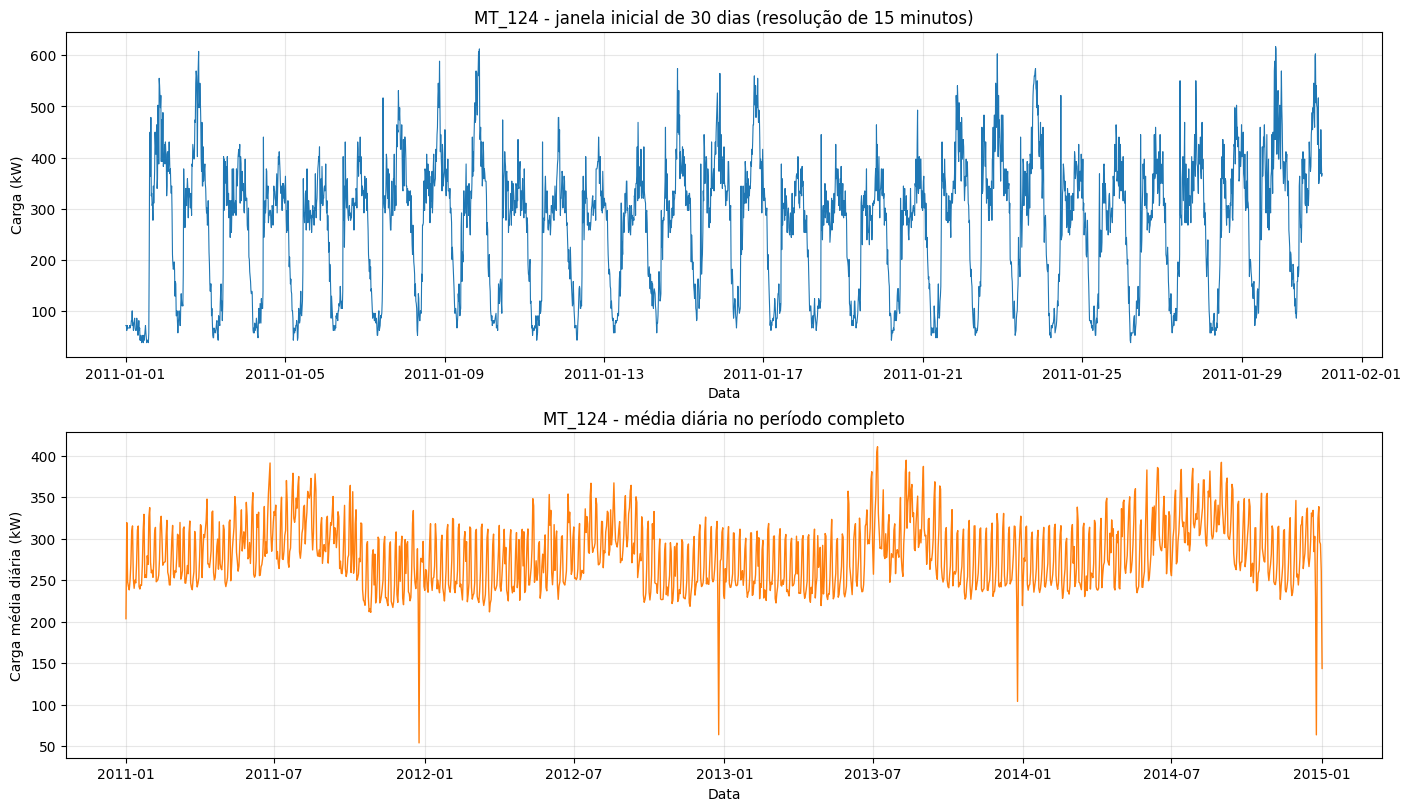

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

serie_cliente = 'MT_124'  # pode trocar para qualquer coluna MT_xxx existente

df_plot = pd.read_csv(
    DATA_PATH,
    sep=';',
    decimal=',',
    usecols=['Unnamed: 0', serie_cliente],
    low_memory=False
)

df_plot = df_plot.rename(columns={'Unnamed: 0': 'timestamp'})
df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df_plot[serie_cliente] = pd.to_numeric(df_plot[serie_cliente], errors='coerce')
df_plot = df_plot.dropna(subset=['timestamp']).sort_values('timestamp')

# Série original em janela curta (30 dias) para observar variação temporal detalhada
inicio_janela = df_plot['timestamp'].min()
fim_janela = inicio_janela + pd.Timedelta(days=30)
janela = df_plot[(df_plot['timestamp'] >= inicio_janela) & (df_plot['timestamp'] <= fim_janela)]

# Série agregada diária para leitura macro de tendência
serie_diaria = df_plot.set_index('timestamp')[serie_cliente].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(janela['timestamp'], janela[serie_cliente], color='tab:blue', linewidth=0.8)
axes[0].set_title(f'{serie_cliente} - janela inicial de 30 dias (resolução de 15 minutos)')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Carga (kW)')
axes[0].grid(alpha=0.3)

axes[1].plot(serie_diaria.index, serie_diaria.values, color='tab:orange', linewidth=1.0)
axes[1].set_title(f'{serie_cliente} - média diária no período completo')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Carga média diária (kW)')
axes[1].grid(alpha=0.3)

plt.show()


# **Referências**

- CÁCERES, G.; TRONCOSO, A.; AGUILERA-MARTOS, I.; RÓDENAS, F.; RUEDA, M.; EXPÓSITO, A.; PÉREZ-CHAMARRO, E. ElectricityLoadDiagrams20112014. UCI Machine Learning Repository, 2014. Disponível em: <https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014>. Acesso em: 28 fev. 2026.

- CÁCERES, G.; TRONCOSO, A.; AGUILERA-MARTOS, I.; RÓDENAS, F.; RUEDA, M.; EXPÓSITO, A.; PÉREZ-CHAMARRO, E. ElectricityLoadDiagrams20112014. DOI: 10.24432/C58C86, 2014.


In [2]:
#@title **Avaliação**
Introducao = 10 #@param {type:"slider", min:0, max:10, step:1}

Fonte_dos_dados = 10 #@param {type:"slider", min:0, max:10, step:1}

Solucao_proposta = 10 #@param {type:"slider", min:0, max:10, step:1}

Referencias = 10 #@param {type:"slider", min:0, max:10, step:1}

In [4]:
#@title **Nota Final**
nota = 0.30*Introducao + 0.30*Fonte_dos_dados + 0.30*Solucao_proposta + 0.10*Referencias

print(f'Nota da entrega {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota da entrega 8.5



,nome,nota
0,Aluno 1,8.5
1,Aluno 2,8.5
2,Aluno 3,8.5
